In [ ]:
import pandas as pd
#imported pandas 

In [2]:
# 1. DATA INGESTION & CLEANING

In [3]:
dataset = pd.read_csv(r"C:\Users\Manish Chahar\Documents\datasets\Churn_Modelling.csv")
dataset.head(6)

,RowNumber,CustomerId,Surname,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
0,1,15634602,Hargrave,619,France,Female,42,2,0.00,1,1,1,101348.88,1
1,2,15647311,Hill,608,Spain,Female,41,1,83807.86,1,0,1,112542.58,0
2,3,15619304,Onio,502,France,Female,42,8,159660.80,3,1,0,113931.57,1
3,4,15701354,Boni,699,France,Female,39,1,0.00,2,0,0,93826.63,0
4,5,15737888,Mitchell,850,Spain,Female,43,2,125510.82,1,1,1,79084.10,0
5,6,15574012,Chu,645,Spain,Male,44,8,113755.78,2,1,0,149756.71,1


In [4]:
# Checking null values in dataset

In [5]:
dataset.isnull().sum()

RowNumber          0
CustomerId         0
Surname            0
CreditScore        0
Geography          0
Gender             0
Age                0
Tenure             0
Balance            0
NumOfProducts      0
HasCrCard          0
IsActiveMember     0
EstimatedSalary    0
Exited             0
dtype: int64

In [6]:
# Dropping identifiers that don't contribute to predictive power to reduce noise

In [7]:
dataset.drop(columns=["RowNumber","CustomerId","Surname"],inplace=True)

In [8]:
x = dataset.iloc[:,:-1]
y = dataset["Exited"]

In [9]:
from sklearn.preprocessing import OneHotEncoder,StandardScaler
from sklearn.pipeline import Pipeline
import xgboost as xgb
from sklearn.compose import ColumnTransformer

In [10]:
# 2. FEATURE ENGINEERING ARCHITECTURE
# Defining feature groups for targeted preprocessing

In [11]:
num_cols = ["CreditScore", "Age", "Tenure", "Balance", "NumOfProducts", "EstimatedSalary"]
cat_cols = ["Geography", "Gender", "HasCrCard", "IsActiveMember"]

In [12]:
# Scaler for numeric stability and Encoder for categorical transformation

In [13]:
num_transfromer = StandardScaler()
cat_transformer = OneHotEncoder(handle_unknown="ignore")

In [14]:
# ColumnTransformer: Streamlining preprocessing to prevent Data Leakage

In [15]:
preprocessor = ColumnTransformer(
    transformers=[
        ('num', num_transfromer, num_cols), # Scaling for numbers
        ('cat', cat_transformer, cat_cols)  # Encoding for categories
    ])

In [16]:
from sklearn.model_selection import train_test_split,RandomizedSearchCV

In [17]:
# 3. MODEL PIPELINE & IMBALANCE HANDLING
# scale_pos_weight is used to handle class imbalance 
# Gamma and Lambda are added to control overfitting (Regularization)

In [18]:
model_pipeline = Pipeline(steps=[
    ("preprocessor",preprocessor),
    
    ("model",xgb.XGBClassifier(eval_metric="logloss", scale_pos_weight=3,gamma = 1,reg_lambda = 10))

])

In [19]:
# 4. HYPERPARAMETER TUNING (Randomized Search)
# Exploring the parameter space efficiently to find the global optimum

In [20]:
param_dist = {
    "model__n_estimators":[200,400,700],
    "model__max_depth":[3,4,5],
    "model__learning_rate":[0.01,0.5,0.1],
    "model__subsample":[0.8,0.9,1.0]
}

In [21]:
x_train, x_test, y_train, y_test = train_test_split(x,y,test_size=0.2,random_state=42,stratify=y)

In [22]:
# Scoring set to 'f1' because accuracy is misleading for imbalanced churn data

In [23]:
rs = RandomizedSearchCV(model_pipeline, param_dist, n_iter=10, cv=5,scoring="f1",random_state=42)
rs.fit(x_train, y_train)

RandomizedSearchCV(cv=5,
                   estimator=Pipeline(steps=[('preprocessor',
                                              ColumnTransformer(transformers=[('num',
                                                                               StandardScaler(),
                                                                               ['CreditScore',
                                                                                'Age',
                                                                                'Tenure',
                                                                                'Balance',
                                                                                'NumOfProducts',
                                                                                'EstimatedSalary']),
                                                                              ('cat',
                                                                               OneHotEncoder(handle_unknown='ignore'),
                                                                               ['Geography',
                                                                                'Gender',
                                                                                'HasCrCard',
                                                                                'IsActiveMember'])])),
                                             ('model',
                                              XGBClassifier(base_score=None,
                                                            booster=Non...
                                                            max_depth=None,
                                                            max_leaves=None,
                                                            min_child_weight=None,
                                                            missing=nan,
                                                            monotone_constraints=None,
                                                            multi_strategy=None,
                                                            n_estimators=None,
                                                            n_jobs=None,
                                                            num_parallel_tree=None, ...))]),
                   param_distributions={'model__learning_rate': [0.01, 0.5,
                                                                 0.1],
                                        'model__max_depth': [3, 4, 5],
                                        'model__n_estimators': [200, 400, 700],
                                        'model__subsample': [0.8, 0.9, 1.0]},
                   random_state=42, scoring='f1')

In [40]:
best_model = rs.best_estimator_
best_model


Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num', StandardScaler(),
                                                  ['CreditScore', 'Age',
                                                   'Tenure', 'Balance',
                                                   'NumOfProducts',
                                                   'EstimatedSalary']),
                                                 ('cat',
                                                  OneHotEncoder(handle_unknown='ignore'),
                                                  ['Geography', 'Gender',
                                                   'HasCrCard',
                                                   'IsActiveMember'])])),
                ('model',
                 XGBClassifier(base_score=None, booster=None, callbacks=None,
                               colsample_bylevel...
                               feature_types=None, feature_weights=None,
                               gamma=1, grow_policy=None, importance_type=None,
                               interaction_constraints=None, learning_rate=0.01,
                               max_bin=None, max_cat_threshold=None,
                               max_cat_to_onehot=None, max_delta_step=None,
                               max_depth=4, max_leaves=None,
                               min_child_weight=None, missing=nan,
                               monotone_constraints=None, multi_strategy=None,
                               n_estimators=400, n_jobs=None,
                               num_parallel_tree=None, ...))])

In [25]:
best_model.score(x_train,y_train)*100, best_model.score(x_test,y_test)*100

(83.3, 82.65)

In [26]:
from sklearn.metrics import confusion_matrix,classification_report

In [27]:
# 5. MODEL EVALUATION

In [28]:
y_pred = best_model.predict(x_test)

print("\n Classification Report \n",classification_report(y_test,y_pred))
print("\n Confusion Matrix \n",confusion_matrix(y_test,y_pred))


 Classification Report 
               precision    recall  f1-score   support

           0       0.92      0.85      0.89      1593
           1       0.56      0.71      0.63       407

    accuracy                           0.83      2000
   macro avg       0.74      0.78      0.76      2000
weighted avg       0.85      0.83      0.83      2000


 Confusion Matrix 
 [[1362  231]
 [ 116  291]]


In [29]:
# 6. FEATURE IMPORTANCE
# Extracting feature names post-encoding for meaningful visualization

In [30]:
preprocessor = best_model.named_steps["preprocessor"]
model = best_model.named_steps["model"]

In [31]:
cat_features = list(preprocessor.named_transformers_["cat"].get_feature_names_out(cat_cols))

all_features = num_cols+cat_features

all_features

['CreditScore',
 'Age',
 'Tenure',
 'Balance',
 'NumOfProducts',
 'EstimatedSalary',
 'Geography_France',
 'Geography_Germany',
 'Geography_Spain',
 'Gender_Female',
 'Gender_Male',
 'HasCrCard_0',
 'HasCrCard_1',
 'IsActiveMember_0',
 'IsActiveMember_1']

In [43]:
importance = model.feature_importances_

In [33]:
feature_importance_df = pd.DataFrame({
    'Feature': all_features,
    'Importance': importance
}).sort_values(by='Importance', ascending=False)

In [34]:
import seaborn as sns
import matplotlib.pyplot as plt

In [35]:
# Visualizaing Business Drivers

C:\Users\Manish Chahar\AppData\Local\Temp\ipykernel_20200\1272900571.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Importance', y='Feature', data=feature_importance_df, palette='viridis')


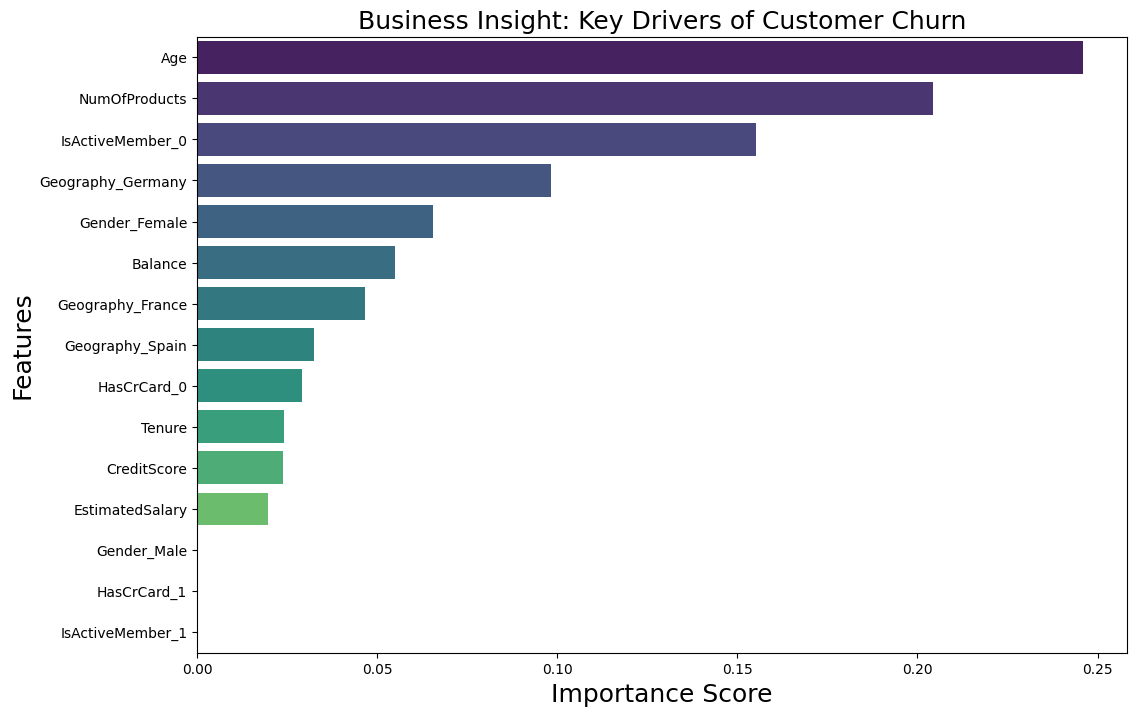

In [36]:
plt.figure(figsize=(12, 8))
sns.barplot(x='Importance', y='Feature', data=feature_importance_df, palette='viridis')
plt.title('Business Insight: Key Drivers of Customer Churn', fontsize=18)
plt.xlabel('Importance Score', fontsize=18)
plt.ylabel('Features', fontsize=18)
plt.show()

In [37]:
# 7. MODEL DEPLOYMENT

In [38]:
import joblib

In [39]:
joblib.dump(best_model,"churn_model_xgb_v1.pkl")
print("Model Saved Successfully!")

Model Saved Successfully!
